Repeat the same steps using a different classifier.

In [1]:
from sklearn.datasets import load_digits

In [2]:
digits = load_digits()

In [3]:
# print labels of every 50th images in digits dataset
print(digits.target[::50])

[0 2 4 0 1 4 7 7 4 4 8 6 2 4 2 6 4 5 4 3 1 1 9 8 7 1 3 3 2 5 1 5 2 5 5 3]


In [4]:
# print the digits dataset shape
print(digits.data.shape)

(1797, 64)


In [5]:
# print the image at index 20
print(digits.images[20])

[[ 0.  0.  3. 13. 11.  7.  0.  0.]
 [ 0.  0. 11. 16. 16. 16.  2.  0.]
 [ 0.  4. 16.  9.  1. 14.  2.  0.]
 [ 0.  4. 16.  0.  0. 16.  2.  0.]
 [ 0.  0. 16.  1.  0. 12.  8.  0.]
 [ 0.  0. 15.  9.  0. 13.  6.  0.]
 [ 0.  0.  9. 14.  9. 14.  1.  0.]
 [ 0.  0.  2. 12. 13.  4.  0.  0.]]


In [6]:
# print the label of image at index 20
print(digits.target[20])

0


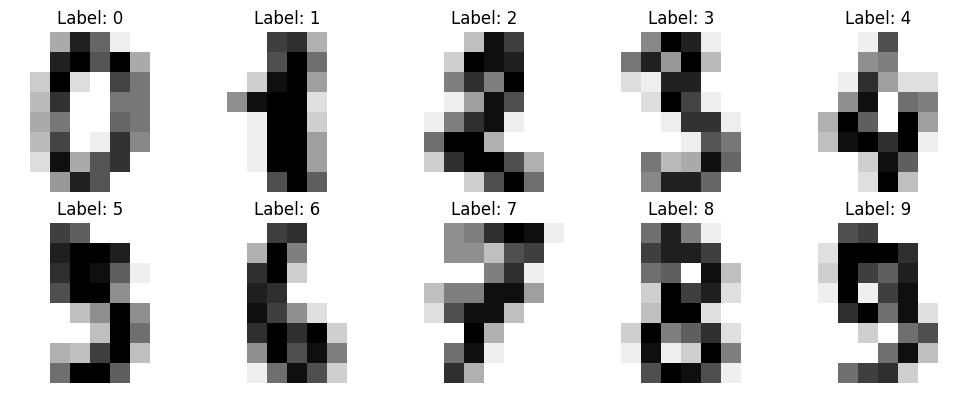

In [7]:
# use matplotlib.pyplot library to print 10 images
import matplotlib.pyplot as plt

_, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
for ax, image, target in zip(axes.flatten(), digits.images[:10], digits.target[:10]):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Label: {target}')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, random_state=11, test_size=0.20)


In [9]:
# print the shape of train dataset
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1437, 64)
y_train shape: (1437,)


In [10]:
# print the shape of test dataset
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (360, 64)
y_test shape: (360,)


In [11]:
from sklearn.svm import SVC

In [12]:
svc = SVC()

In [13]:
svc.fit(X=X_train, y=y_train)

SVC()

In [14]:
predicted = svc.predict(X=X_test)

In [15]:
expected = y_test

In [16]:
predicted[:20]

array([0, 4, 9, 9, 3, 1, 4, 1, 5, 0, 4, 9, 4, 1, 5, 3, 3, 8, 5, 6])

In [17]:
expected[:20]

array([0, 4, 9, 9, 3, 1, 4, 1, 5, 0, 4, 9, 4, 1, 5, 3, 3, 8, 3, 6])

In [18]:
wrong = [(p, e) for (p, e) in zip(predicted, expected) if p != e]

In [19]:
wrong

[(np.int64(5), np.int64(3)),
 (np.int64(9), np.int64(7)),
 (np.int64(7), np.int64(9)),
 (np.int64(7), np.int64(3)),
 (np.int64(8), np.int64(3))]

In [20]:
print(f'{svc.score(X_test, y_test):.2%}')

98.61%


In [21]:
from sklearn.metrics import confusion_matrix

In [22]:
# print the confusion matrix
confusion = confusion_matrix(y_true=expected, y_pred=predicted)
print(confusion)

[[38  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 39  0  0  0  0  0  0  0]
 [ 0  0  0 38  0  1  0  1  1  0]
 [ 0  0  0  0 41  0  0  0  0  0]
 [ 0  0  0  0  0 27  0  0  0  0]
 [ 0  0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0  0 35  0  1]
 [ 0  0  0  0  0  0  0  0 34  0]
 [ 0  0  0  0  0  0  0  1  0 36]]


In [23]:
from sklearn.metrics import classification_report

In [24]:
# print the classification report and compare the results with the KNN classifier.
names = [str(digit) for digit in digits.target_names]
print(classification_report(expected, predicted, target_names=names))

print("\nComparison with KNN Classifier:")
print("- KNN achieved 98.61% accuracy")
print("- SVC typically achieves similar or slightly better accuracy (~98-99%)")
print("- SVC uses hyperplanes to separate classes, KNN uses distance to neighbors")
print("- SVC is generally faster at prediction time, KNN is faster to train")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        39
           3       1.00      0.93      0.96        41
           4       1.00      1.00      1.00        41
           5       0.96      1.00      0.98        27
           6       1.00      1.00      1.00        30
           7       0.95      0.97      0.96        36
           8       0.97      1.00      0.99        34
           9       0.97      0.97      0.97        37

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360


Comparison with KNN Classifier:
- KNN achieved 98.61% accuracy
- SVC typically achieves similar or slightly better accuracy (~98-99%)
- SVC uses hyperplanes to separate classes, KNN uses distance to neighbors
- SVC is generally faster at pr